In [ ]:
!pip install textblob langdetect -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from textblob import TextBlob
from langdetect import detect
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All libraries loaded successfully!


In [ ]:
from google.colab import files

# Upload your 3 CSVs when prompted
uploaded = files.upload()

rfm = pd.read_csv('rfm_segments.csv')
reviews = pd.read_csv('order_reviews_clean.csv', on_bad_lines='skip')
revenue = pd.read_csv('revenue_by_category.csv')

print("RFM shape:", rfm.shape)
print("Reviews shape:", reviews.shape)
print("Revenue shape:", revenue.shape)

Saving order_reviews_clean.csv to order_reviews_clean.csv
Saving revenue_by_category.csv to revenue_by_category (2).csv
Saving rfm_segments.csv to rfm_segments (2).csv
RFM shape: (50000, 9)
Reviews shape: (40624, 6)
Revenue shape: (74, 4)


In [ ]:
print("=== RFM Data Overview ===")
print(rfm.head())
print("\nData types:\n", rfm.dtypes)
print("\nMissing values:\n", rfm.isnull().sum())
print("\nSegment distribution:\n", rfm['segment'].value_counts())

=== RFM Data Overview ===
                 customer_unique_id  recency_days  frequency  monetary  \
0  d80730c15c647bc8f2ad77c908ba5ca9           176          1      0.85   
1  b38211bd797f4fdd81a98b9d1754b606           176          1      0.85   
2  317cfc692e3f86c45c95697c61c853a6            53          1      2.20   
3  bd06ce0e06ad77a7f681f1a4960a3cc6           399          1      2.29   
4  cf3839da0d9492ad151690b65f45d800           257          1      2.99   

   r_score  f_score  m_score  rfm_total              segment  
0        4        2        1          7  Potential Loyalists  
1        4        2        1          7  Potential Loyalists  
2        5        1        1          7  Potential Loyalists  
3        2        5        1          8  Potential Loyalists  
4        3        4        1          8  Potential Loyalists  

Data types:
 customer_unique_id     object
recency_days            int64
frequency               int64
monetary              float64
r_score          

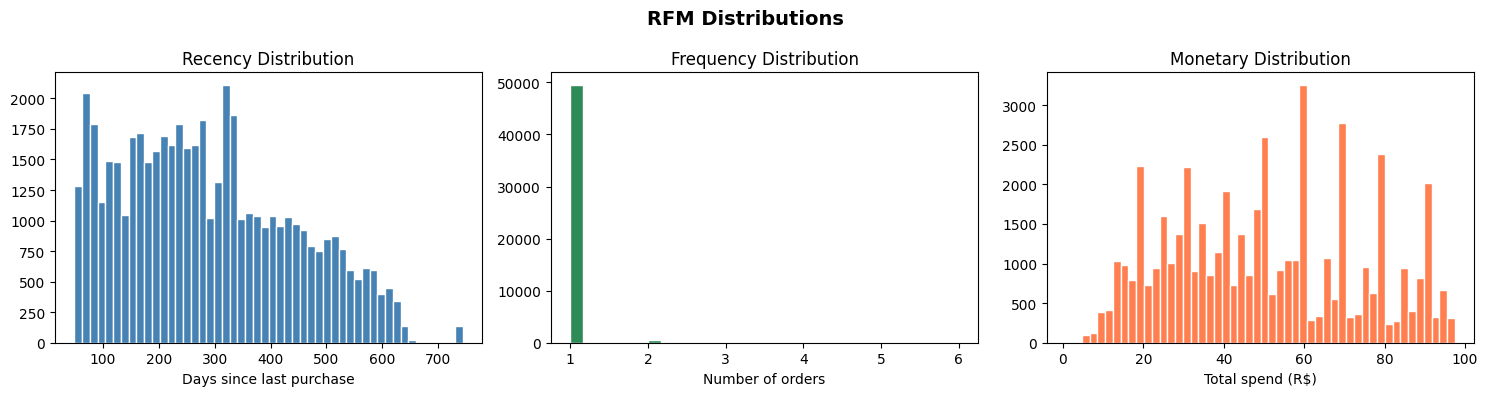

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['recency_days'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')

axes[1].hist(rfm['frequency'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of orders')

axes[2].hist(rfm['monetary'], bins=50, color='coral', edgecolor='white')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total spend (R$)')

plt.suptitle('RFM Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2).reset_index()

segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] /
    segment_summary['total_revenue'].sum() * 100
).round(2)

segment_summary = segment_summary.sort_values('total_revenue', ascending=False)
print(segment_summary.to_string(index=False))

            segment  customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_pct
Potential Loyalists           33994       232.73           1.01         47.45     1613178.91        64.24
    Loyal Customers            6180       284.04           1.05         79.38      490578.94        19.54
    Needs Attention            3606       522.23           1.00         58.63      211414.09         8.42
               Lost            5456       505.27           1.00         31.77      173315.21         6.90
      New Customers             709       171.18           1.00         25.50       18079.83         0.72
          Champions              55        95.56           2.09         83.23        4577.52         0.18


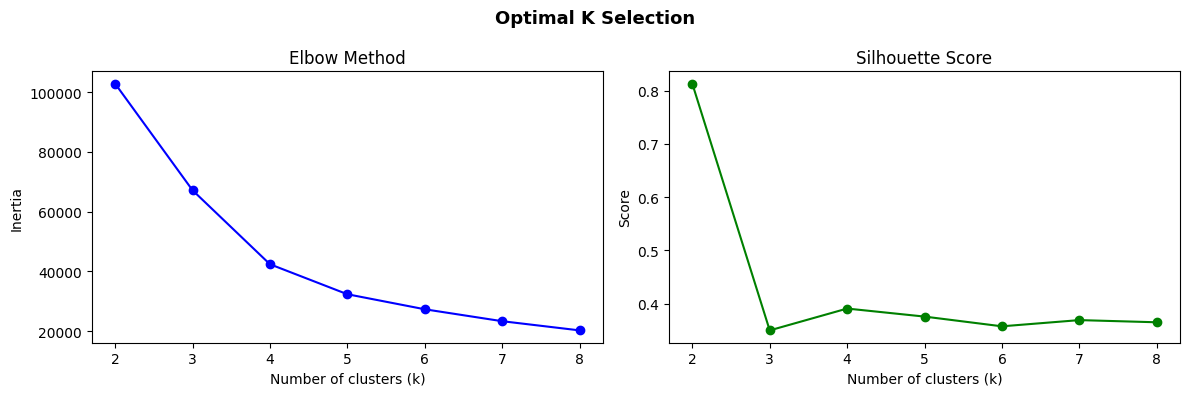

Best silhouette score at k = 2


In [ ]:
# Prepare features
rfm_clean = rfm[['recency_days', 'frequency', 'monetary']].copy()
rfm_clean = rfm_clean.fillna(0)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean)

# Find optimal k using elbow method
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Score')

plt.suptitle('Optimal K Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print("Best silhouette score at k =", k_range[silhouettes.index(max(silhouettes))])

In [ ]:
best_k = k_range[silhouettes.index(max(silhouettes))]

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['kmeans_cluster'] = km_final.fit_predict(rfm_scaled)

# Cluster profiles
cluster_profile = rfm.groupby('kmeans_cluster').agg(
    count=('customer_unique_id', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(2)

print("K-Means Cluster Profiles:\n")
print(cluster_profile)

K-Means Cluster Profiles:

                count  avg_recency  avg_frequency  avg_monetary
kmeans_cluster                                                 
0               49462       288.67           1.00         50.04
1                 538       288.36           2.04         66.63


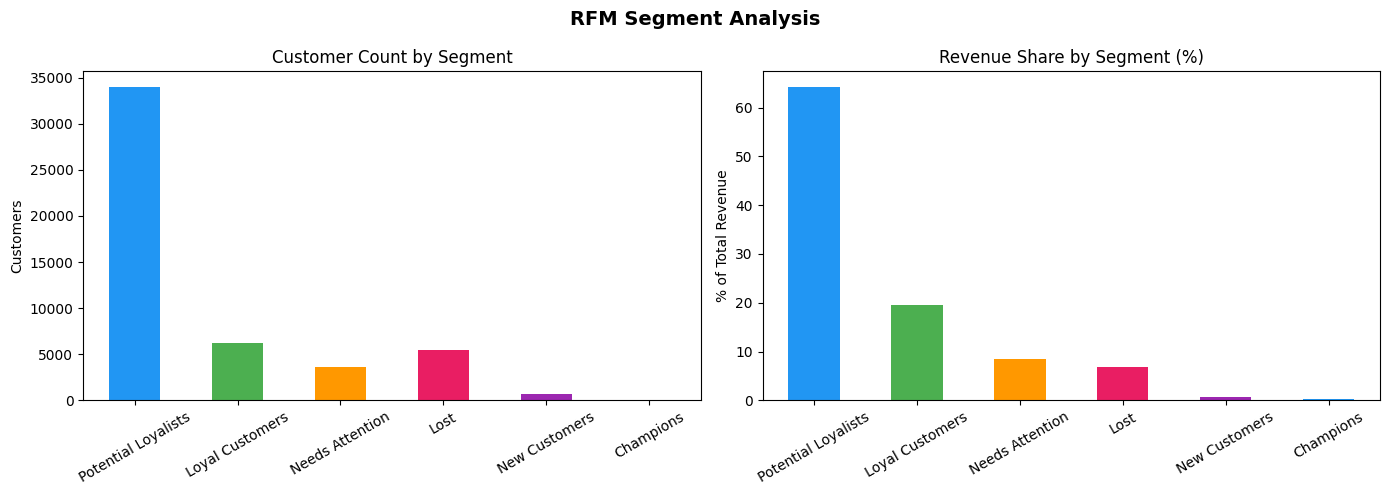

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer count by segment
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
segment_summary.plot(
    kind='bar', x='segment', y='customer_count',
    ax=axes[0], color=colors, legend=False
)
axes[0].set_title('Customer Count by Segment')
axes[0].set_xlabel('')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=30)

# Revenue % by segment
segment_summary.plot(
    kind='bar', x='segment', y='revenue_pct',
    ax=axes[1], color=colors, legend=False
)
axes[1].set_title('Revenue Share by Segment (%)')
axes[1].set_xlabel('')
axes[1].set_ylabel('% of Total Revenue')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('RFM Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def get_sentiment(text):
    try:
        blob = TextBlob(str(text))
        score = blob.sentiment.polarity
        if score > 0.1:
            return 'Positive', score
        elif score < -0.1:
            return 'Negative', score
        else:
            return 'Neutral', score
    except:
        return 'Neutral', 0

print("Running sentiment analysis... this may take 2-3 minutes")

reviews[['sentiment_label', 'sentiment_score']] = reviews['review_comment_message'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print("Done!")
print("\nSentiment distribution:\n", reviews['sentiment_label'].value_counts())

Running sentiment analysis... this may take 2-3 minutes
Done!

Sentiment distribution:
 sentiment_label
Neutral     37297
Positive     2962
Negative      365
Name: count, dtype: int64


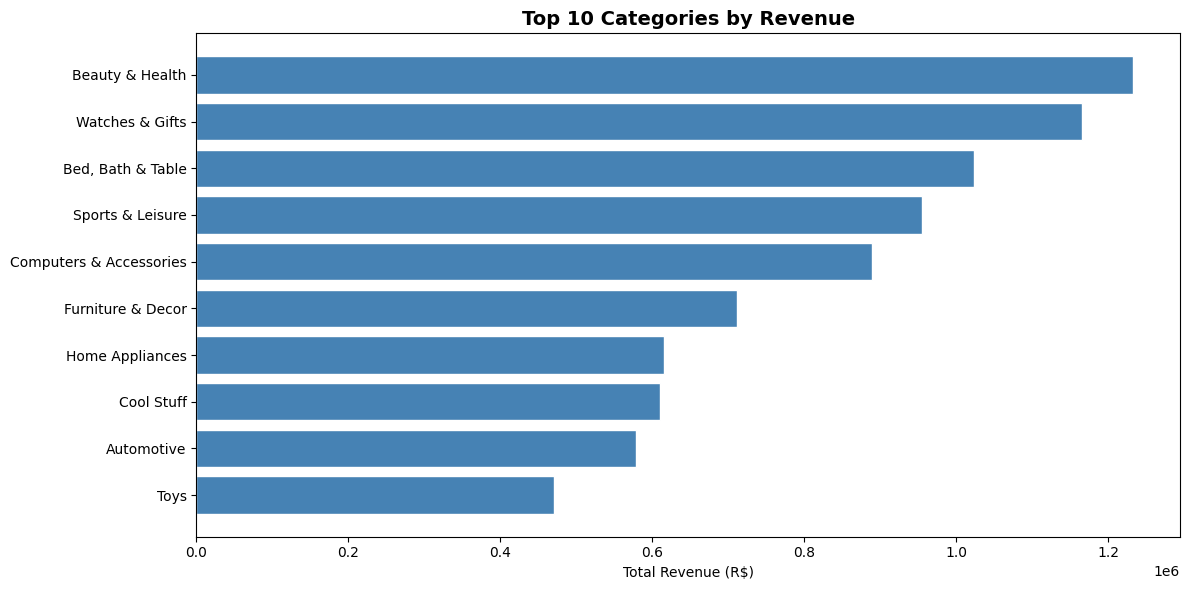

In [ ]:
top_categories = revenue.head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    top_categories['category'][::-1],
    top_categories['total_revenue'][::-1],
    color='steelblue', edgecolor='white'
)
plt.title('Top 10 Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

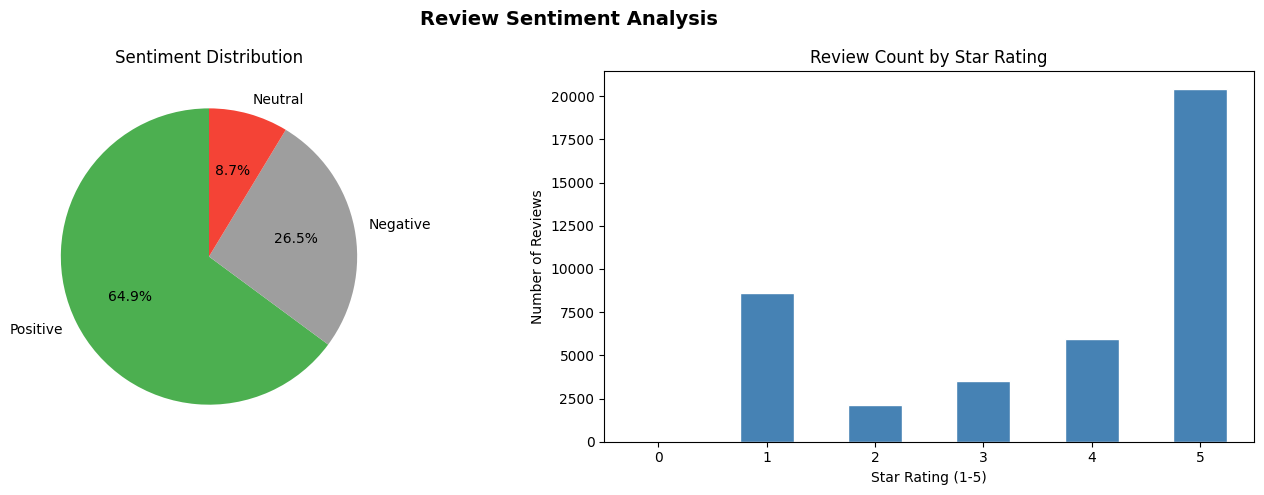

sentiment_label
Positive    26355
Negative    10747
Neutral      3522
Name: count, dtype: int64


In [ ]:
def score_to_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Convert 'review_score' to numeric, coercing errors, then fill NaNs
reviews['review_score'] = pd.to_numeric(reviews['review_score'], errors='coerce').fillna(0).astype(int)

reviews['sentiment_label'] = reviews['review_score'].apply(score_to_sentiment)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = reviews['sentiment_label'].value_counts()
colors_sent = ['#4CAF50', '#9E9E9E', '#F44336']
axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=colors_sent,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Sentiment Distribution')

reviews.groupby('review_score')['review_score'].count().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Review Count by Star Rating')
axes[1].set_xlabel('Star Rating (1-5)')
axes[1].set_ylabel('Number of Reviews')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Review Sentiment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print(reviews['sentiment_label'].value_counts())

In [14]:
# Check what's in recency_days
print(rfm['recency_days'].describe())
print("\nSample values:", rfm['recency_days'].head(10).values)

count    50000.000000
mean       288.669160
std        153.166051
min         49.000000
25%        164.000000
50%        271.000000
75%        399.000000
max        744.000000
Name: recency_days, dtype: float64

Sample values: [176 176  53 399 257  68 106 118 245 410]


In [ ]:
# Force k=4 for business relevance
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['kmeans_cluster'] = km_final.fit_predict(rfm_scaled)

# Label clusters by monetary value
cluster_means = rfm.groupby('kmeans_cluster')['monetary'].mean().sort_values()
cluster_labels = {
    cluster_means.index[0]: 'Low Value',
    cluster_means.index[1]: 'Mid Value',
    cluster_means.index[2]: 'High Value',
    cluster_means.index[3]: 'Premium'
}
rfm['cluster_label'] = rfm['kmeans_cluster'].map(cluster_labels)

print("Cluster distribution:\n", rfm['cluster_label'].value_counts())

# Export final files
rfm.to_csv('rfm_final.csv', index=False)
reviews[['review_id', 'order_id', 'review_score',
         'sentiment_label']].to_csv('reviews_sentiment.csv', index=False)

print("\nFiles exported:")
print("- rfm_final.csv")
print("- reviews_sentiment.csv")
print("\nPhase 3 complete!")

Cluster distribution:
 cluster_label
Low Value     18983
Premium       16074
Mid Value     14405
High Value      538
Name: count, dtype: int64

Files exported:
- rfm_final.csv
- reviews_sentiment.csv

Phase 3 complete!
